In [1]:
# Download data kurs USD/IDR dari Yahoo Finance dan flatten multi-level columns
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

START = '2001-06-28'
# end = besok agar hari ini selalu inklusif (yfinance end bersifat exclusive)
END   = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

df = yf.download('USDIDR=X', start=START, end=END)

# Flatten multi-level columns (Price, Ticker) menjadi satu level
df.columns = df.columns.droplevel(1)

# Validasi: tampilkan 5 baris terakhir untuk konfirmasi data terkini sudah masuk
print("=== 5 Baris Terakhir ===")
print(df[['Open', 'High', 'Low', 'Close']].tail(5).to_string())
print(f"\nTotal rows    : {len(df)}")
print(f"Rentang       : {df.index[0].date()} s.d. {df.index[-1].date()}")
print(f"Close terakhir: {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})")

[*********************100%***********************]  1 of 1 completed

=== 5 Baris Terakhir ===
Price               Open          High           Low         Close
Date                                                              
2026-05-18  17586.000000  17708.699219  17519.199219  17586.000000
2026-05-19  17701.000000  17764.000000  17648.800781  17701.000000
2026-05-20  17708.500000  17797.000000  17539.699219  17777.000000
2026-05-21  17654.300781  17726.000000  17616.199219  17658.400391
2026-05-22  17668.000000  17716.000000  17668.000000  17700.000000

Total rows    : 6285
Rentang       : 2001-06-28 s.d. 2026-05-22
Close terakhir: 17,700.00 IDR  (2026-05-22)


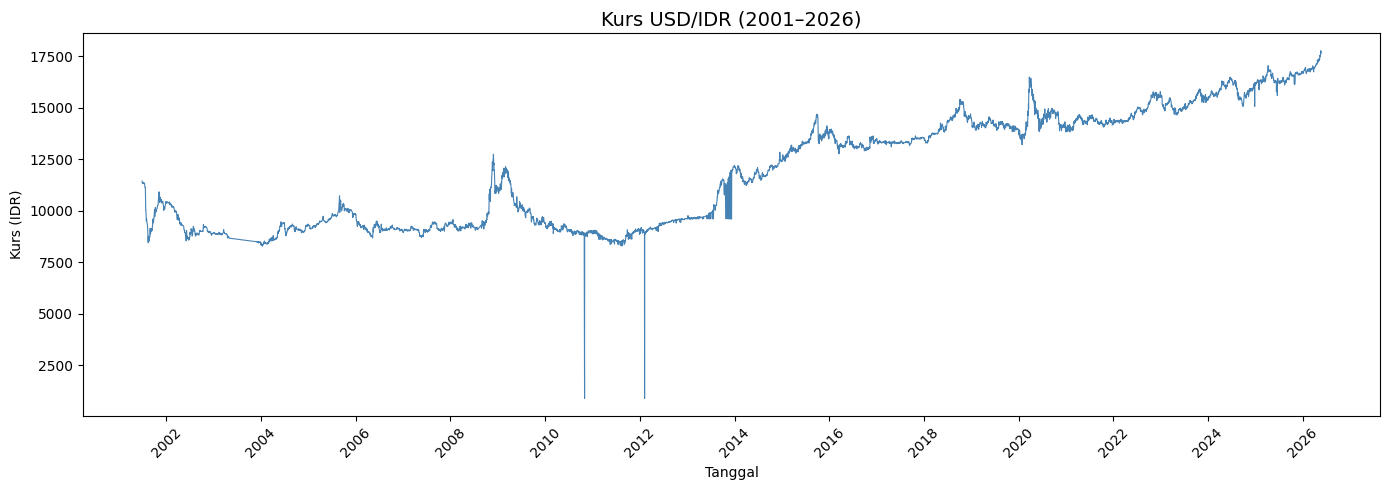

In [2]:
# Eksplorasi: visualisasi time series kurs USD/IDR
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], linewidth=0.8, color='steelblue')
ax.set_title('Kurs USD/IDR (2001–2026)', fontsize=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# Cek missing values dan statistik deskriptif kolom Close
print("Missing values per kolom:")
print(df.isnull().sum())

print(f"\nStatistik kolom Close:")
print(df['Close'].describe())

# Isi missing value dengan forward fill jika ada
df['Close'] = df['Close'].ffill()
print(f"\nMissing values setelah forward fill: {df['Close'].isnull().sum()}")

Missing values per kolom:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Statistik kolom Close:
count     6285.000000
mean     11965.145035
std       2697.999431
min        888.109985
25%       9240.500000
50%      11842.000000
75%      14320.000000
max      17777.000000
Name: Close, dtype: float64

Missing values setelah forward fill: 0


In [4]:
# Pakai first difference (perubahan harian) agar model belajar fluktuasi, bukan tren absolut
from sklearn.preprocessing import MinMaxScaler

data_raw = df['Close'].values.astype(float)

# data_diff[i] = Close[i+1] - Close[i] — bisa positif maupun negatif
data_diff = np.diff(data_raw)

# Normalisasi ke [-1, 1] karena perubahan bisa positif dan negatif
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data_diff.reshape(-1, 1))

print(f"Shape data asli       : {data_raw.shape}")
print(f"Shape first difference: {data_diff.shape}")
print(f"Shape scaled          : {data_scaled.shape}")
print(f"Range perubahan harian: {data_diff.min():+.1f} s.d. {data_diff.max():+.1f} IDR")

Shape data asli       : (6285,)
Shape first difference: (6284,)
Shape scaled          : (6284, 1)
Range perubahan harian: -8036.1 s.d. +8038.0 IDR


In [5]:
# Buat dataset dengan sliding window 60 hari
WINDOW = 60

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, WINDOW)
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Shape X : (6224, 60)
Shape y : (6224,)


In [6]:
# Split data 80% train / 20% test (tanpa shuffle — urutan waktu dipertahankan)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape ke (samples, timesteps, features) untuk input LSTM
X_train = X_train.reshape(-1, WINDOW, 1)
X_test  = X_test.reshape(-1, WINDOW, 1)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (4979, 60, 1)
Test  : (1245, 60, 1)


In [7]:
# Definisi arsitektur model LSTM sederhana
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

I0000 00:00:1779438772.754150   59379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779438772.780459   59379 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779438773.317580   59379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1779438773.529523   59379 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0012 - val_loss: 3.1634e-04 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 3.1283e-04 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 3.0741e-04 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010 - val_loss: 2.9560e-04 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4662e-04 - val_loss: 2.8924e-04 - learning_rate: 0.0010
Epoch 6/100
139/141 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.7112e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.4644e-04 - val_loss: 2.8818e-04 - learning_rate: 0.0010
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.4490e-04 - val_loss: 2.9299e-04 - learning_rate: 5.0000e-04
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━

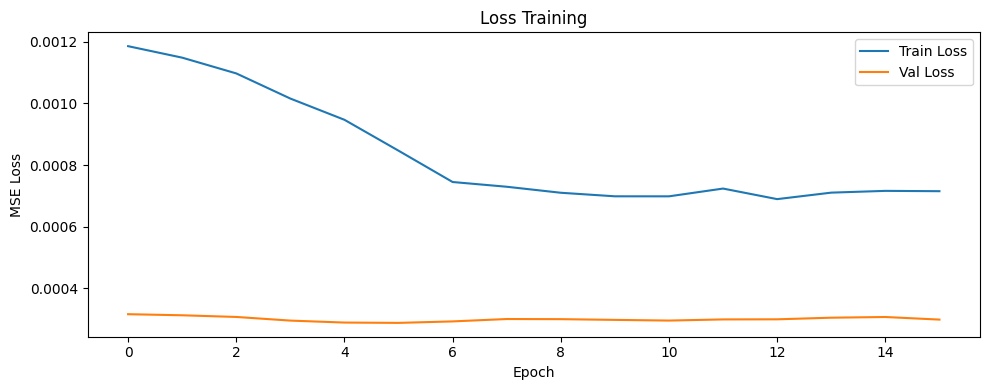

In [8]:
# Training model dengan early stopping dan learning rate scheduler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# Plot loss training vs validasi
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Evaluasi model: rekonstruksi harga dari prediksi perubahan harian
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled = model.predict(X_test)

# Inverse transform → perubahan harian dalam IDR
y_pred_diff = scaler.inverse_transform(y_pred_scaled).flatten()
y_true_diff = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Single-step reconstruction: setiap prediksi pakai harga aktual hari sebelumnya
# y[i] memprediksi data_raw[WINDOW+split+i+1], titik awalnya data_raw[WINDOW+split+i]
prev_prices  = data_raw[WINDOW + split : WINDOW + split + len(y_test)]
y_pred_price = prev_prices + y_pred_diff
y_true_price = data_raw[WINDOW + split + 1 : WINDOW + split + 1 + len(y_test)]

mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

print(f"MAE  : {mae:,.2f} IDR")
print(f"RMSE : {rmse:,.2f} IDR")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE  : 56.37 IDR
RMSE : 86.76 IDR


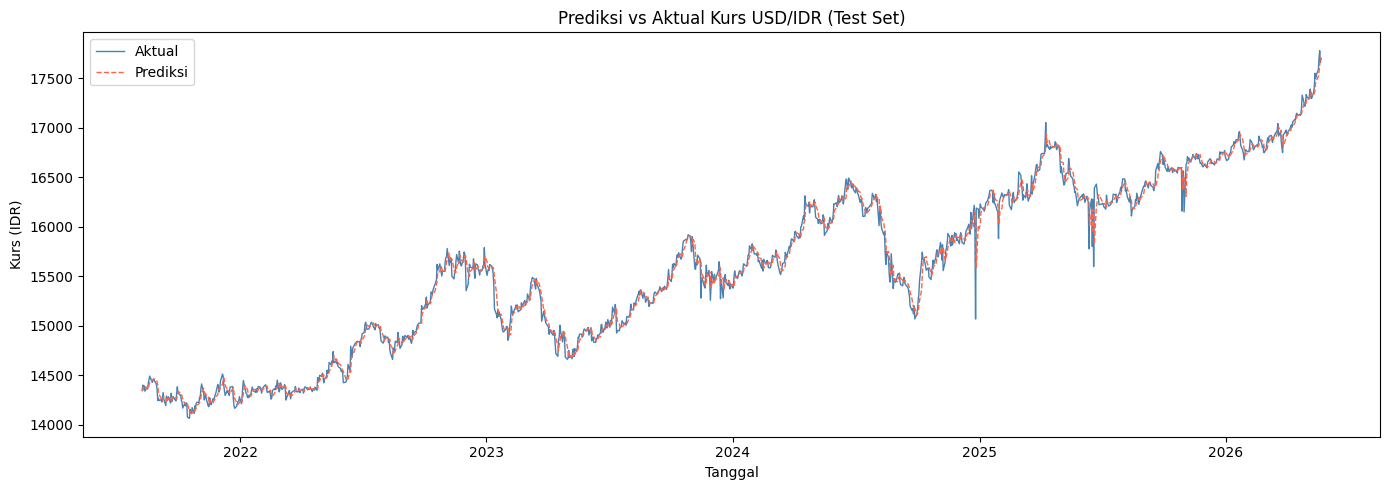

In [10]:
# Plot prediksi vs nilai aktual pada data test
# index dimulai dari WINDOW+split+1 karena first difference menggeser satu posisi
test_dates = df.index[WINDOW + split + 1 : WINDOW + split + 1 + len(y_test)]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true_price, label='Aktual',   linewidth=1.0, color='steelblue')
plt.plot(test_dates, y_pred_price, label='Prediksi', linewidth=1.0, color='tomato', linestyle='--')
plt.title('Prediksi vs Aktual Kurs USD/IDR (Test Set)')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.show()

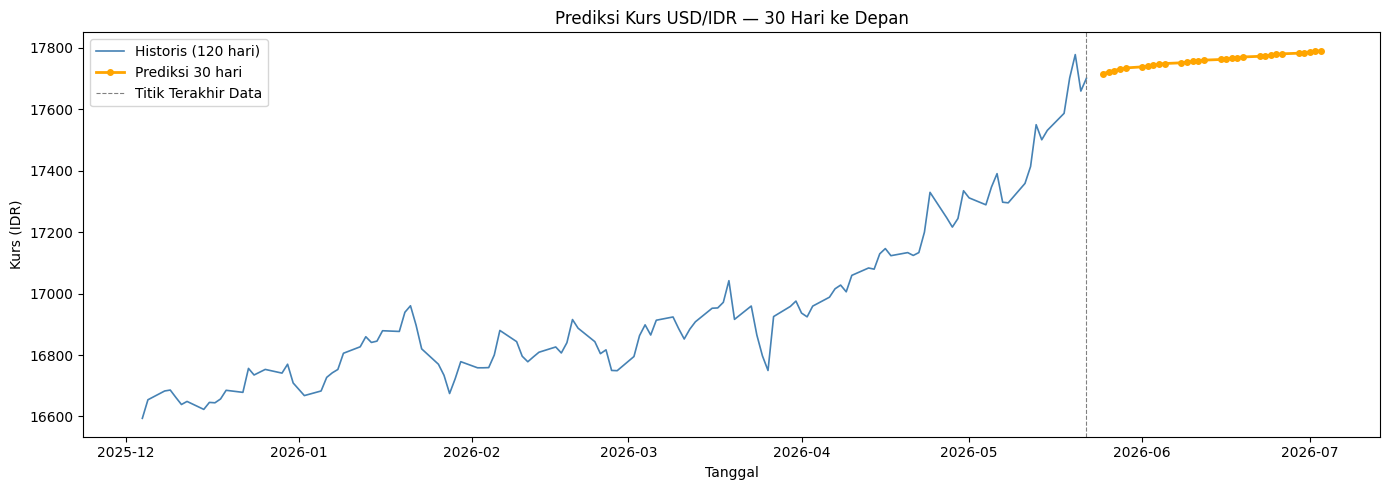

   Tanggal  Prediksi Kurs (IDR)
2026-05-25                17714
2026-05-26                17720
2026-05-27                17725
2026-05-28                17729
2026-05-29                17733
2026-06-01                17737
2026-06-02                17740
2026-06-03                17742
2026-06-04                17745
2026-06-05                17747
2026-06-08                17750
2026-06-09                17752
2026-06-10                17754
2026-06-11                17756
2026-06-12                17758
2026-06-15                17761
2026-06-16                17763
2026-06-17                17765
2026-06-18                17767
2026-06-19                17769
2026-06-22                17771
2026-06-23                17773
2026-06-24                17775
2026-06-25                17777
2026-06-26                17779
2026-06-29                17781
2026-06-30                17783
2026-07-01                17785
2026-07-02                17787
2026-07-03                17789


In [11]:
# Prediksi 30 hari ke depan — rekonstruksi kumulatif dari perubahan harian
FORECAST_DAYS = 30

last_seq   = data_scaled[-WINDOW:].reshape(1, WINDOW, 1)
last_price = data_raw[-1]  # Close terakhir sebagai titik awal rekonstruksi

future_changes_scaled = []
for _ in range(FORECAST_DAYS):
    pred = model.predict(last_seq, verbose=0)[0, 0]
    future_changes_scaled.append(pred)
    last_seq = np.append(last_seq[:, 1:, :], [[[pred]]], axis=1)

# Inverse transform → perubahan harian dalam IDR
future_changes = scaler.inverse_transform(
    np.array(future_changes_scaled).reshape(-1, 1)
).flatten()

# Rekonstruksi harga kumulatif dari perubahan
future_prices = [last_price]
for c in future_changes:
    future_prices.append(future_prices[-1] + c)
future_prices = np.array(future_prices[1:]).reshape(-1, 1)

# Buat tanggal prediksi (hari kerja)
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

# Plot historis 120 hari + prediksi
plt.figure(figsize=(14, 5))
plt.plot(df.index[-120:], data_raw[-120:], label='Historis (120 hari)', color='steelblue', linewidth=1.2)
plt.plot(future_dates, future_prices, label='Prediksi 30 hari', color='orange', linewidth=2, marker='o', markersize=4)
plt.axvline(x=last_date, color='gray', linestyle='--', linewidth=0.8, label='Titik Terakhir Data')
plt.title('Prediksi Kurs USD/IDR — 30 Hari ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Kurs (IDR)')
plt.legend()
plt.tight_layout()
plt.show()

# Tabel prediksi
pred_df = pd.DataFrame({
    'Tanggal': future_dates.strftime('%Y-%m-%d'),
    'Prediksi Kurs (IDR)': future_prices.flatten().astype(int)
})
print(pred_df.to_string(index=False))